# **Univariate Analysis (Phân tích đơn biến)**

Trong phần này, chúng ta sẽ khảo sát từng biến độc lập nhằm:
1. Đánh giá phân phối của dữ liệu (Distribution) bằng Histogram và KDE.
2. Phát hiện các giá trị ngoại lai (Outliers) thông qua Boxplot.
3. Chuẩn đoán độ lệch (Skewness):
   - **Lệch phải (Right Skew):** Mean > Median
   - **Lệch trái (Left Skew):** Mean < Median
4. Từ việc phân tích phân phối và độ lệch, đưa ra chiến lược xử lý dữ liệu thiếu (Missing values): Ưu tiên dùng **Median** cho dữ liệu lệch/có outliers và **Mean** cho dữ liệu phân phối chuẩn.
5. **Lưu ý về giá trị 0:** Trong các audio features (acousticness, instrumentalness, mode...), giá trị 0 là các biểu hiện thuộc tính âm nhạc có thật (VD: nhạc không lời, thang âm thứ), không phải lỗi dữ liệu.

In [2]:
# Cell gọi dữ liệu
import pandas as pd 
import os
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('Đang khai báo dữ liệu')

# Dữ liệu thô ban đầu
file_path = os.path.join("..", "Data", "train.csv")

df = pd.read_csv(file_path)

print('Khai báo thành công')

Đang khai báo dữ liệu
Khai báo thành công


## **Bảng Phân Phối Các Thể Loại Nhạc (Class 0 - 10)**

Dựa trên từ điển dữ liệu, dưới đây là danh sách đối chiếu giữa các nhãn số và thể loại nhạc tương ứng:

| Class | Thể loại nhạc (Genre) | | Class | Thể loại nhạc (Genre) |
|:-----:|:----------------------|---|:-----:|:----------------------|
| **0** | Acoustic/Folk         | | **6** | Indie Alt             |
| **1** | Alt Music             | | **7** | Instrumental          |
| **2** | Blues                 | | **8** | Metal                 |
| **3** | Bollywood             | | **9** | Pop                   |
| **4** | Country               | | **10**| Rock                  |
| **5** | Hip Hop               | |       |                       |

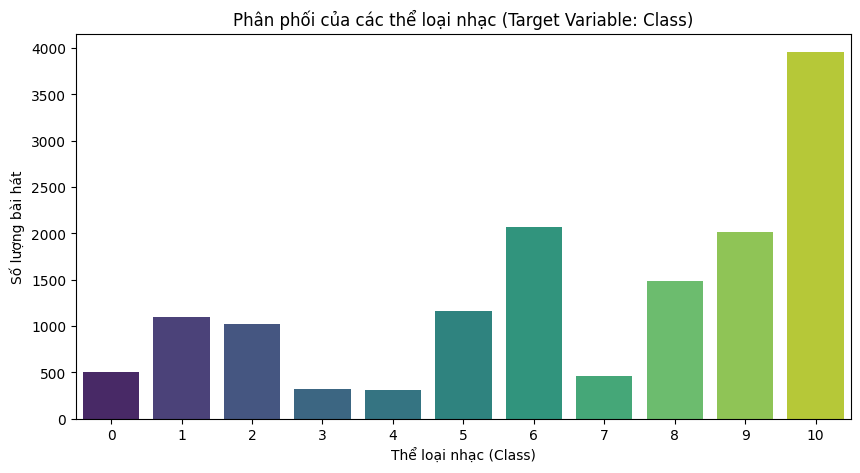

In [5]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Class', palette='viridis')
plt.title('Phân phối của các thể loại nhạc (Target Variable: Class)')
plt.xlabel('Thể loại nhạc (Class)')
plt.ylabel('Số lượng bài hát')
plt.show()

biểu đồ cho thấy một sự chênh lệch cực kỳ lớn khi Class 10 (Rock) có tới hơn 4000 mẫu, vượt xa các class khác (ví dụ Class 1, 2, 3 chỉ loanh quanh khoảng vài trăm mẫu). Đây là trạng thái Mất cân bằng dữ liệu (Imbalanced Data) rất điển hình trong máy học.

**1. Nguyên nhân thực tế (Dưới góc độ phân phối gốc):**

Sự mất cân bằng này không hẳn là do thu thập lỗi, mà nó phản ánh khá sát xác suất tiên nghiệm của các thể loại nhạc ngoài thực tế. Nhạc Rock và Pop (Class 9 và 10) có số lượng bài hát và lượng người nghe khổng lồ trên các nền tảng streaming. Do đó, một tập mẫu ngẫu nhiên sẽ tự nhiên chứa tỷ trọng lớn các bài hát này, lấn át hoàn toàn các dòng nhạc mang tính đặc thù hơn như Blues hay Instrumental.

**2. Tác động rủi ro đến mô hình học máy:**
- Nghịch lý độ chính xác: Nếu một thuật toán tồi chỉ cần đoán "mù" rằng mọi bài hát đưa vào đều thuộc Class 10, nó vẫn có thể đạt độ chính xác khá cao nhờ vào lượng mẫu áp đảo này. Điều này tạo ra một ảo giác rằng mô hình đang học tốt.

- Thiên lệch vùng ranh giới quyết định: Khi chạy các thuật toán tối ưu hóa, hàm mất mát sẽ bị chi phối bởi Class 10. Hậu quả là ranh giới phân loại sẽ bị kéo lệch, khiến mô hình có xu hướng dự đoán nhầm các class thiểu số thành Class 10 để tối thiểu hóa sai số tổng thể.

Từ biểu đồ phân phối số lượng bài hát theo từng thể loại, chúng ta rút ra các kết luận quan trọng sau:

1. **Hiện tượng mất cân bằng dữ liệu (Imbalanced Data):** Tập dữ liệu bị mất cân bằng trầm trọng. Class `10` (Rock) chiếm số lượng áp đảo (>4000 mẫu), trong khi các Class khác như `1` (Alt Music), `2` (Blues), `3` (Bollywood) lại có rất ít dữ liệu.
2. **Nguyên nhân thực tế:** Điều này phản ánh đúng xu hướng ngoài đời thực khi Rock và Pop thường có số lượng bản thu âm khổng lồ so với các thể loại ngách.
3. **Chiến lược xử lý cho mô hình:** - **Đánh giá mô hình:** Tuyệt đối không sử dụng `Accuracy` làm thước đo chính vì sẽ dẫn đến "Nghịch lý độ chính xác" (Model cứ đoán bừa là Rock cũng sẽ có điểm cao). Thay vào đó, phải dùng `F1-Score (Macro)`.
   - **Tiền xử lý (Preprocessing):** Cần xem xét áp dụng kỹ thuật sinh dữ liệu nhân tạo **SMOTE** (Oversampling) cho tập huấn luyện, hoặc sử dụng tham số **Class Weights** (gán trọng số phạt) khi định nghĩa thuật toán Machine Learning để giúp mô hình "chú ý" hơn đến các class thiểu số.

## **Phân tích chuyên sâu các đặc trưng âm thanh**

Sau khi nắm bắt được sự phân bố của biến mục tiêu (Class), chúng ta sẽ tiến hành phân tích đơn biến (Univariate Analysis) cho các thuộc tính âm thanh. Để có cái nhìn rõ nét nhất về đặc thù của dữ liệu âm nhạc, chúng ta sẽ khảo sát hai biến có tính chất hoàn toàn đối lập nhau:
* **`energy` (Năng lượng):** Đại diện cho cường độ, sự ồn ào và nhịp điệu mạnh mẽ (thường cao ở nhạc điện tử, Rock).
* **`acousticness` (Độ mộc mạc):** Đại diện cho mức độ thuần âm thanh mộc, không dùng thiết bị điện tử (thường cao ở nhạc cổ điển, Folk, Acoustic).

**Mục tiêu của phần này:** Sử dụng kết hợp hai công cụ trực quan hóa mạnh mẽ nhất cho biến liên tục:
1. **Biểu đồ Hộp (Boxplot):** Để nhận diện sự hiện diện và mức độ phân tán của các giá trị ngoại lai (Outliers).
2. **Biểu đồ Phân phối (Histogram kết hợp KDE):** Để đánh giá hình dáng phân phối của dữ liệu, xác định hướng lệch (Skewness) giữa giá trị trung bình (Mean) và trung vị (Median).

Việc so sánh trực tiếp hai biến đối lập này sẽ giúp chúng ta đưa ra quyết định tiền xử lý dữ liệu (Scaling, Transformation) chính xác nhất cho các mô hình nhạy cảm với phân phối như Naive Bayes và KNN ở các bước sau.

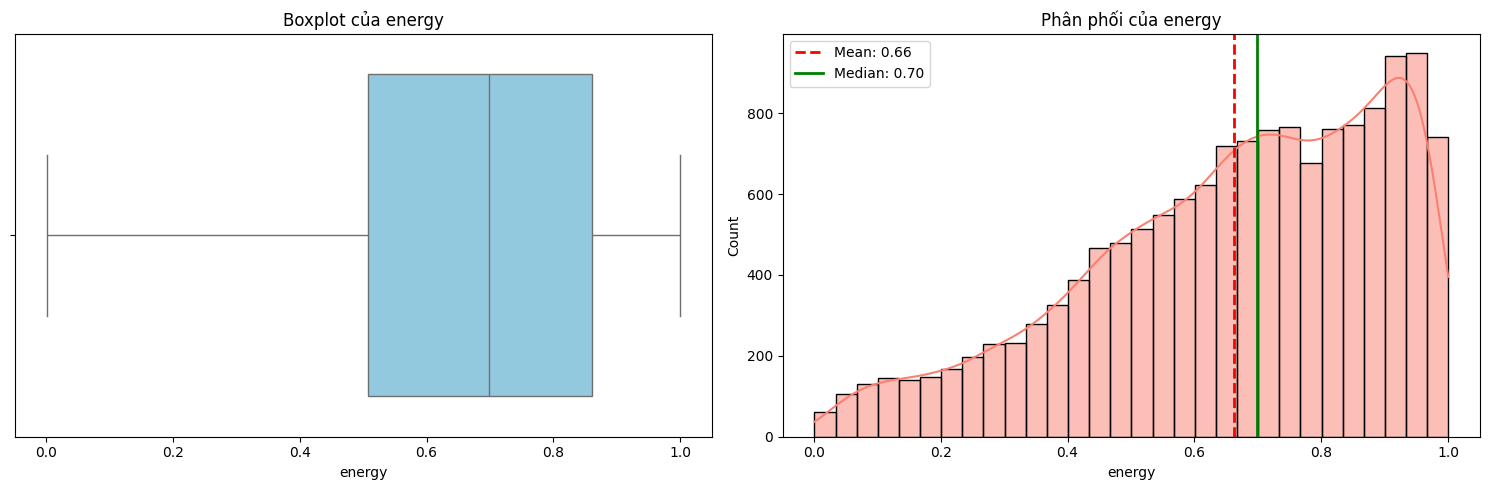

--- Báo cáo cho đặc trưng: energy ---
Skewness: -0.657
-> Phân phối lệch TRÁI (Left Skewed). Khuyến nghị điền khuyết (nếu có): MEDIAN
--------------------------------------------------



In [6]:
# Phân tích đơn biến cho thuộc tính Energy
analyze_numeric_feature(df, 'energy')

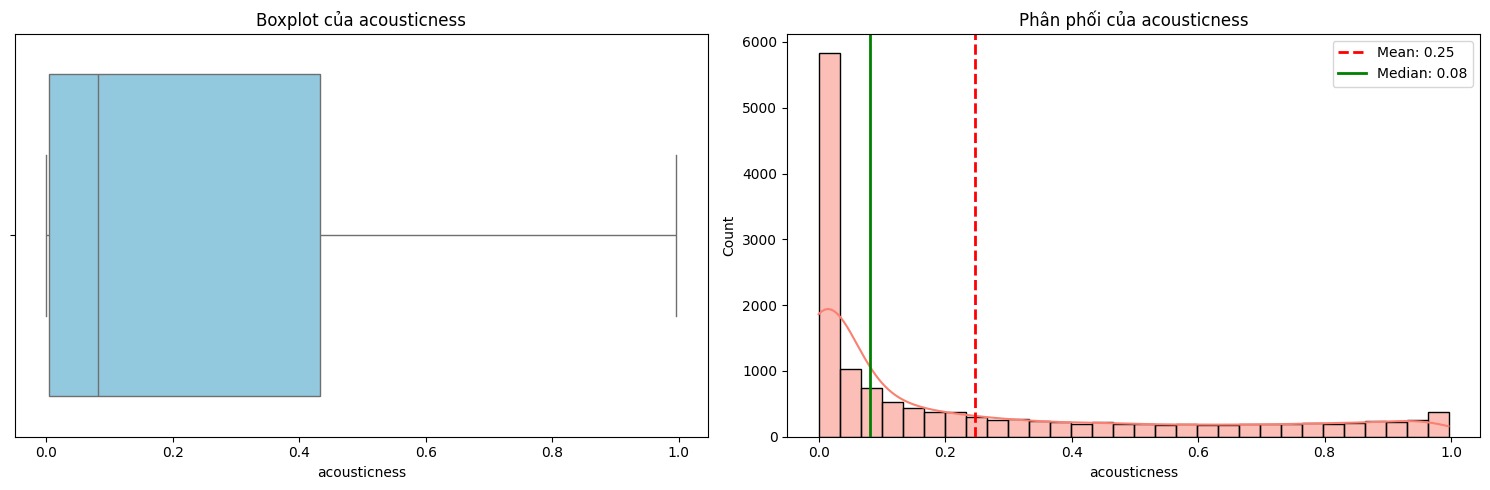

--- Báo cáo cho đặc trưng: acousticness ---
Skewness: 1.109
-> Phân phối lệch PHẢI (Right Skewed). Khuyến nghị điền khuyết (nếu có): MEDIAN
--------------------------------------------------



In [7]:
# Phân tích đơn biến cho thuộc tính Acousticness
analyze_numeric_feature(df, 'acousticness')

**1. Định nghĩa hai biến số**
- Energy (Năng lượng): Đây là thước đo từ 0.0 đến 1.0 thể hiện mức độ cường độ, nhịp điệu và sự ồn ào của một bài hát. Các bài hát có giá trị energy cao thường mang cảm giác nhanh, mạnh mẽ, và ồn ào (ví dụ: nhạc Rock, Heavy Metal). Các bài hát có giá trị thấp thường nhẹ nhàng, êm dịu (ví dụ: nhạc cổ điển, nhạc thiền).

- Acousticness (Độ mộc mạc): Là chỉ số (từ 0.0 đến 1.0) đánh giá mức độ tin cậy rằng bài hát được chơi bằng nhạc cụ mộc (không sử dụng nhạc cụ điện tử hay âm thanh tổng hợp). Điểm tiến gần về 1.0 nghĩa là bài hát thuần acoustic (ví dụ: guitar gỗ, piano cơ), điểm tiến về 0 nghĩa là bài hát sử dụng nhiều âm thanh điện tử (ví dụ: EDM, Pop hiện đại).

**2. Phân tích độ lệch và Cách khắc phục tổng quát**
Dựa vào biểu đồ Histogram & KDE:

**A. Biến energy (Lệch trái - Negative / Left Skewness):**
- Đặc điểm: Đuôi của biểu đồ kéo dài về phía bên trái. Dữ liệu tập trung chủ yếu ở phía bên phải (giá trị cao, từ 0.6 đến 0.9). Điều này có nghĩa là Mean < Median. Đại đa số các bài hát trong tập dữ liệu này là nhạc có nhịp điệu mạnh, sôi động.
- Cách khắc phục tổng quát: Để làm cho dữ liệu có phân phối chuẩn hơn (kéo dữ liệu dãn ra về bên phải), chúng ta thường áp dụng các phép biến đổi:
    - Bình phương ($x^2$) hoặc Lập phương ($x^3$).
    - Sử dụng phép biến đổi Yeo-Johnson (rất hiệu quả và tự động xử lý được cả số âm nếu có, mặc dù ở đây từ 0-1).
    
**B. Biến acousticness (Lệch phải - Positive / Right Skewness):**
- Đặc điểm: Đuôi biểu đồ kéo dài rất xa về phía bên phải. Phần lớn dữ liệu tập trung ở gốc tọa độ (gần mức 0.0). Điều này có nghĩa là Mean > Median. Thể hiện rõ tập dữ liệu của bạn đa số là các bài hát sử dụng âm thanh điện tử/phòng thu.
- Cách khắc phục tổng quát: Để "thu gọn" phần đuôi dài này và làm phân phối cân đối hơn, ta dùng:
    - Biến đổi Logarit (np.log1p(x) để tránh log(0)).
    - Lấy căn bậc hai: Biến đổi Box-Cox (chỉ dùng cho số strictly positive > 0) hoặc Yeo-Johnson.

**3. Phân tích Boxplot, Outliers và Mức độ ảnh hưởng đến mô hình**

**A. Phân tích Boxplot:**
- energy: Các điểm ngoại lai chỉ xuất hiện ở phía dưới cùng (gần 0). Đây là những bài hát cực kỳ yên tĩnh, hiếm hoi lọt thỏm giữa một "rừng" nhạc sôi động.

- acousticness: Có vô số điểm ngoại lai ở phía trên (kéo dài tới 1.0). Đây là những bài hát thuần nhạc cụ mộc (Acoustic/Folk) nằm trong một tập dữ liệu áp đảo bởi nhạc điện tử.

- Kết luận cốt lõi: Đây là các Outliers có ý nghĩa. Chúng đại diện cho các đặc trưng cực kỳ quan trọng giúp mô hình phân loại được các thể loại nhạc ngách (như Acoustic, Classical, Blues). Tuyệt đối không được xóa bỏ các dòng dữ liệu này.

**B. Ảnh hưởng của phân phối lệch và Outliers đến dữ liệu Train (Đặc biệt với Naive Bayes, KNN, Rule-Based):**

*Thuật toán Naive Bayes (Gaussian Naive Bayes):*

Ảnh hưởng: Thuật toán này có một giả định cực kỳ quan trọng là các biến liên tục (như energy, acousticness) phải tuân theo phân phối chuẩn (Normal/Gaussian Distribution). Với dữ liệu lệch quá mạnh như thế này, Naive Bayes sẽ hoạt động kém hiệu quả vì nó tính toán xác suất (Mean, Variance) bị sai lệch.

Xử lý: BẮT BUỘC phải áp dụng Power Transformer (Yeo-Johnson/Box-Cox) để ép 2 biến này về dạng hình quả chuông (phân phối chuẩn) trước khi đưa vào mô hình Naive Bayes.

*Thuật toán K-Nearest Neighbor (KNN):*

Ảnh hưởng: KNN dựa vào tính toán khoảng cách (Euclidean, Manhattan). Outliers và sự chênh lệch thang đo sẽ kéo lệch khoảng cách này, khiến các điểm dữ liệu "Acoustic" bị đẩy ra quá xa.

Xử lý: Cần thiết phải Chuẩn hóa dữ liệu. Do có nhiều Outliers, bạn không nên dùng MinMaxScaler hay StandardScaler (vì mean và variance bị nhiễu). Hãy dùng RobustScaler (Sử dụng Median và IQR) để chuẩn hóa cho thuật toán KNN.

*Thuật toán Rule-Based (hoặc Tree-Based như Decision Tree):*

Ảnh hưởng: Các mô hình dựa trên quy luật hoặc cây quyết định chia cắt không gian dữ liệu (splitting) nên chúng hoàn toàn không bị ảnh hưởng bởi độ lệch (Skewness) hay Outliers.

Xử lý: Không cần biến đổi gì, có thể để nguyên dữ liệu thô đưa vào mô hình.

## **Biểu đồ Tỷ lệ Dữ liệu Thiếu**
Một mô hình Machine Learning chỉ tốt khi dữ liệu đầu vào của nó đủ "sạch" và "toàn vẹn". Đặc biệt, với các thuật toán dựa trên việc tính toán khoảng cách như *K-Nearest Neighbor (KNN)*, sự xuất hiện của giá trị Null (NaN) sẽ gây lỗi hệ thống lập tức. Với thuật toán *Naive Bayes*, dữ liệu thiếu làm sai lệch việc tính toán xác suất tiên nghiệm.

Do đó, mục tiêu của phần phân tích này không chỉ là phát hiện các lỗ hổng dữ liệu, mà quan trọng hơn là *thiết lập một chiến lược điền khuyết* bài bản nhằm phục hồi tối đa lượng thông tin bị mất, đồng thời không làm biến dạng cấu trúc phân phối gốc của dữ liệu.

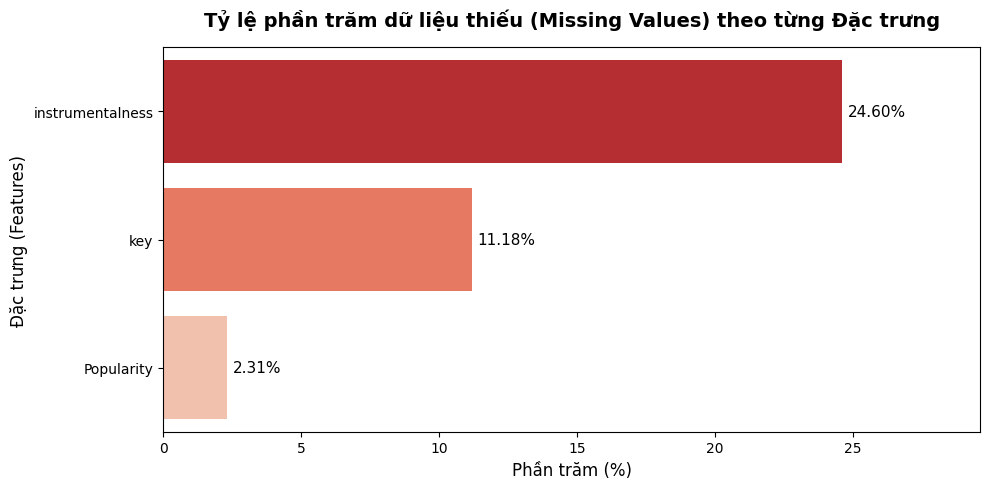

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính phần trăm dữ liệu thiếu cho từng cột
missing_percentages = (df.isnull().sum() / len(df)) * 100
# Lọc ra các cột lớn hơn 0% và sắp xếp giảm dần
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

if not missing_percentages.empty:
    plt.figure(figsize=(10, 5))
    
    # Sử dụng palette màu đỏ để cảnh báo dữ liệu lỗi/thiếu
    sns.barplot(x=missing_percentages.values, y=missing_percentages.index, palette='Reds_r')
    
    plt.title('Tỷ lệ phần trăm dữ liệu thiếu (Missing Values) theo từng Đặc trưng', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Phần trăm (%)', fontsize=12)
    plt.ylabel('Đặc trưng (Features)', fontsize=12)
    
    # Gắn label % hiển thị trực tiếp lên từng thanh bar
    for i, v in enumerate(missing_percentages.values):
        plt.text(v + 0.2, i, f"{v:.2f}%", va='center', fontsize=11, color='black')
        
    plt.xlim(0, max(missing_percentages) + 5) # Mở rộng trục X để không bị cắt chữ
    plt.tight_layout()
    plt.show()
else:
    print("Tuyệt vời! Tập dữ liệu không có giá trị khuyết thiếu nào.")

**Kết quả khảo sát Tỷ lệ Missing Values:**
Từ biểu đồ, chúng ta nhận diện được 3 đặc trưng cần được "chữa lành":

1. **`instrumentalness` (Thiếu ~24.60%):**
   - *Tính chất:* Đây là mức độ thiếu hụt nghiêm trọng (gần 1/4 tập dữ liệu). `instrumentalness` là chỉ số cốt lõi để phân tách các nhánh nhạc thuần nhạc cụ (Classical, Jazz) với nhạc có lời (Pop, Rap). Việc xóa cột hay xóa dòng sẽ làm suy giảm nghiêm trọng sức mạnh dự đoán của mô hình Rule-Based.
   - *Chiến lược phục hồi:* Như đã phân tích ở phần phân phối, `instrumentalness` bị *lệch phải rất nặng* (đa số bài hát có giá trị tiến về 0). Do đó, sử dụng Mean sẽ gây sai số lớn do bị kéo lệch bởi các Outliers. Giải pháp tối ưu và an toàn nhất là *Median Imputation* (Điền khuyết bằng Trung vị).

2. **`key` (Thiếu ~11.18%):**
   - *Tính chất:* Cao độ là một biến mang tính phân loại (Categorical/Discrete) với các giá trị số nguyên từ 0 đến 11, đại diện cho các nốt nhạc tiêu chuẩn (C, C#, D,...).
   - *Chiến lược phục hồi:* Việc tính Mean hay Median cho một nốt nhạc là không hợp lý về mặt lý thuyết âm nhạc (bạn không thể có nốt nhạc "trung bình cộng" giữa C và D). Thay vào đó, ta sẽ sử dụng *Mode Imputation* (Điền khuyết bằng Giá trị xuất hiện nhiều nhất - Ký hiệu âm nhạc phổ biến nhất trong tập dữ liệu) để bảo toàn tính logic của thuộc tính này.

3. **`Popularity` (Thiếu ~2.31%):**
   - *Tính chất:* Tỷ lệ thiếu rất nhỏ, thuộc dạng MCAR (Missing Completely At Random - Khuyết thiếu ngẫu nhiên).
   - *Chiến lược phục hồi:* Việc điền khuyết bằng *Median* (hoặc Mean) sẽ rất an toàn và gần như không gây ra bất kỳ xáo trộn nào đến phương sai của tập dữ liệu.

**=> Kết luận hướng hành động:** Bằng cách áp dụng các kỹ thuật Imputation đặc thù cho từng loại biến (Median cho biến liên tục bị lệch, Mode cho biến phân loại), chúng ta sẽ bảo toàn được 100% số lượng mẫu huấn luyện, giải quyết triệt để rào cản NaN cho thuật toán KNN, và cung cấp một bộ dữ liệu có độ tin cậy cao nhất cho quá trình Modeling sắp tới.

## **Biểu đồ Tần suất cho Biến Rời rạc**
Bên cạnh các biến số học liên tục, dữ liệu âm thanh còn chứa các thuộc tính rời rạc đặc thù của lý thuyết âm nhạc, tiêu biểu nhất là `mode` và `key`. Việc phân tích hình dáng phân phối của các biến này giúp chúng ta định hình phương pháp mã hóa phù hợp nhất cho mô hình sau này.

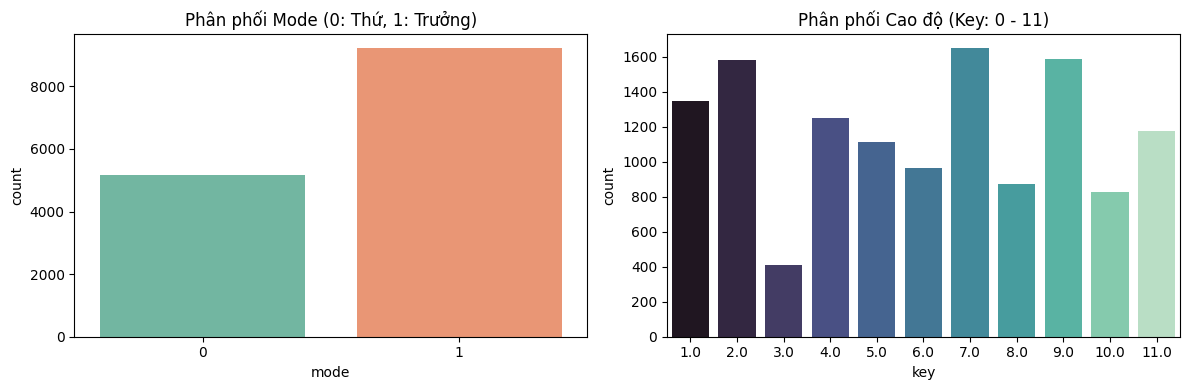

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cột Mode
sns.countplot(data=df, x='mode', palette='Set2', ax=axes[0])
axes[0].set_title('Phân phối Mode (0: Thứ, 1: Trưởng)')

# Cột Key
sns.countplot(data=df, x='key', palette='mako', ax=axes[1])
axes[1].set_title('Phân phối Cao độ (Key: 0 - 11)')

plt.tight_layout()
plt.show()

**1. Phân tích biến `mode` (Thang âm: Trưởng/Thứ):**
- *Nhận xét:* `mode` là một biến nhị phân (Binary) với 2 giá trị hợp lệ duy nhất: `0` (Thứ - Minor) và `1` (Trưởng - Major). Biểu đồ cho thấy tỷ lệ bài hát mang âm hưởng Trưởng (1) áp đảo với số lượng gần gấp đôi âm hưởng Thứ (0). Đây là dữ liệu thực tế mang tính chính xác cao, phản ánh xu hướng thị hiếu âm nhạc đại chúng (đa phần nhạc Pop/Rock có giai điệu vui tươi thuộc giọng Trưởng).
- *Chiến lược xử lý:* Đây là dữ liệu nhị phân chuẩn, không có nhiễu và hoàn toàn sạch. Nó có thể được đưa trực tiếp vào bất kỳ mô hình nào (Naive Bayes, KNN, Rule-Based) mà không cần qua bước biến đổi nào thêm. Đặc biệt với Rule-Based, `mode` là một điều kiện phân nhánh cực kỳ mạnh mẽ để chia tách các dòng nhạc buồn (Blues, Doom Metal) với nhạc sôi động.

**2. Phân tích biến `key` (Cao độ cơ bản):**
- *Nhận xét:* Biến `key` nhận các giá trị số nguyên từ `0` đến `11` (tương ứng với 12 nốt nhạc cơ bản trong âm nhạc phương Tây: C, C#, D,...). Dữ liệu phân bổ khá đều và không có giá trị nào ngoài vùng này (không có nhiễu vô lý). Nốt `0` (Đô - C), `7` (Sol - G), và `2` (Rê - D) xuất hiện nhiều nhất, hoàn toàn khớp với thực tế vì đây là các hợp âm dễ đánh nhất trên Guitar và Piano.
- *Chiến lược xử lý (Rất quan trọng cho KNN):* Mặc dù `key` được ghi nhận dưới dạng "số" (0, 1, 2...), nhưng về bản chất nó là *biến định danh*. Nốt số 11 (B) không hề "lớn hơn" hay "mạnh hơn" nốt số 1 (C#). Nếu ta giữ nguyên dạng số nguyên này để đưa vào thuật toán *K-Nearest Neighbor (KNN)*, mô hình sẽ tính toán sai lệch khoảng cách Euclid (nó sẽ coi nốt 1 và nốt 11 cách nhau rất xa, trong khi thực tế trên vòng tròn bậc 5 chúng có mối liên hệ khác). 
- *Kết luận hành động:* Trước khi đưa vào huấn luyện KNN, biến `key` bắt buộc phải được chuyển đổi bằng kỹ thuật *One-Hot Encoding* (tạo ra 12 cột nhị phân riêng biệt) để loại bỏ tính "thứ tự" giả tạo, giúp đảm bảo "độ sạch" và tính công bằng về khoảng cách.

## **Đánh giá các biến Định danh và Văn bản**
- **Cột `Id`:** Là định danh duy nhất cho mỗi bài hát, không mang giá trị học máy -> **Quyết định: Xóa cột.**
- **Cột `Artist Name` & `Track Name`:** Là dữ liệu văn bản tự do. Trừ khi chúng ta áp dụng các kỹ thuật Xử lý ngôn ngữ tự nhiên (NLP) phức tạp như TF-IDF hay Word2Vec, việc mã hóa hàng ngàn tên nghệ sĩ/bài hát sẽ gây ra hiện tượng bùng nổ chiều dữ liệu làm KNN và Naive Bayes bị quá tải. -> **Quyết định: Tạm thời xóa cột trong giai đoạn Baseline Model.**

Dựa trên toàn bộ quá trình Khám phá Dữ liệu Đơn biến (EDA Univariate), dưới đây là các chỉ định bắt buộc phải thực hiện trước khi đưa dữ liệu vào huấn luyện cho 3 thuật toán (Rule-Based, KNN, Naive Bayes):

| Vấn đề Dữ liệu | Đặc trưng (Features) bị ảnh hưởng | Phương pháp xử lý (Action Plan) | Thuật toán hưởng lợi nhất |
|:---|:---|:---|:---|
| **Dữ liệu khuyết thiếu (NaN)** | `instrumentalness`, `Popularity` | Điền khuyết bằng Trung vị (**Median Imputation**) | KNN, Naive Bayes |
| | `key` | Điền khuyết bằng Mode (**Mode Imputation**) | KNN, Naive Bayes |
| **Mất cân bằng dữ liệu** | Biến mục tiêu `Class` | Dùng **SMOTE** (Oversampling) hoặc gán **Class Weights** | Cả 3 thuật toán |
| **Dữ liệu lệch (Skewness)** | `acousticness`, `liveness`, `speechiness`... | Biến đổi Logarit (**Log1p**) hoặc Yeo-Johnson | Naive Bayes |
| **Ngoại lai (Outliers)** | `duration_in min/ms`, `instrumentalness`... | **Giữ nguyên** (Đây là dữ liệu nhạc thực tế). Dùng **Robust Scaler** để chuẩn hóa thay vì Standard Scaler | KNN |
| **Mã hóa (Encoding)** | `key` (Cao độ 0-11) | Mã hóa **One-Hot Encoding** | KNN |
| | `mode` (0 và 1) | Giữ nguyên | Cả 3 thuật toán |
| **Biến nhiễu / Không cần thiết** | `Id`, `Artist Name`, `Track Name` | Xóa khỏi tập huấn luyện | Cả 3 thuật toán |

In [2]:
# Cấu trúc lưu ảnh hoặc file csv hoặc dữ liệu nào cần thiết
# Đây là cấu trúc lưu file csv, nhưng hầu như công đoạn này lưu ảnh
# --> dùng AI để sửa lại cho đúng ảnh mún lưu

now = datetime.now().strftime("%Y%m%d_%H%M%S")

filename = f"{now}_data_univariateAnalysis.csv"
filepath = os.path.join("..", "Notebooks", "EDA", "UnivariateAnalysis", filename)
os.makedirs(os.path.dirname(filepath), exist_ok=True)

df.to_csv(filepath, index=False)

print("Saved:", filepath)

Saved: ..\Notebooks\EDA\UnivariateAnalysis\20260512_085243_data_univariateAnalysis.csv
